# 1. Setup e carregamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

# carregar dados
df = pd.read_csv("data/df_final.csv")

# ordenar
df = df.sort_values("ano").reset_index(drop=True)

print(df.head())
print(df.info())

    ano  gini  pib_per_capita  inflacao       pib_ipea  gasto_social  \
0  2001  58.4     6823.033185  0.618333  109646.291667  5.665788e+08   
1  2002  58.1     6944.622576  0.991667  124065.591667  6.746159e+08   
2  2003  57.6     6941.439659  0.745833  143162.533333  7.500185e+08   
3  2004  56.5     7258.781017  0.612500  163145.925000  9.334566e+08   
4  2005  56.3     7409.568280  0.462500  180882.050000  1.053933e+09   

   export_pct_gdp   log_pib  log_social  
0       12.371711  8.828206   20.155127  
1       14.230590  8.845867   20.329654  
2       15.180784  8.845409   20.435608  
3       16.545762  8.890105   20.654405  
4       15.243829  8.910662   20.775794  
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ano             13 non-null     int64  
 1   gini            13 non-null     float64
 2   pib_per_capita  13 non-null     float64

# 2. Feature Engineering

In [2]:
# logs
df["log_pib"] = np.log(df["pib_ipea"])
df["log_social"] = np.log(df["gasto_social"])

# crescimento (ESSENCIAL)
df["pib_growth"] = df["pib_ipea"].pct_change()
df["social_growth"] = df["gasto_social"].pct_change()
df["pib_pc_growth"] = df["pib_per_capita"].pct_change()

# interação estado + mercado
df["estado_mercado"] = df["log_pib"] * df["log_social"]

# dummy boom commodities
df["boom"] = (df["ano"] <= 2008).astype(int)

# pós crise
df["pos_crise"] = (df["ano"] >= 2009).astype(int)

# remover NaN de crescimento
df = df.dropna().reset_index(drop=True)

print(df.head())

    ano  gini  pib_per_capita  inflacao       pib_ipea  gasto_social  \
0  2002  58.1     6944.622576  0.991667  124065.591667  6.746159e+08   
1  2003  57.6     6941.439659  0.745833  143162.533333  7.500185e+08   
2  2004  56.5     7258.781017  0.612500  163145.925000  9.334566e+08   
3  2005  56.3     7409.568280  0.462500  180882.050000  1.053933e+09   
4  2006  55.6     7622.039194  0.258333  200787.508333  1.231429e+09   

   export_pct_gdp    log_pib  log_social  pib_growth  social_growth  \
0       14.230590  11.728566   20.329654    0.131507       0.190683   
1       15.180784  11.871736   20.435608    0.153926       0.111771   
2       16.545762  12.002400   20.654405    0.139585       0.244578   
3       15.243829  12.105600   20.775794    0.108713       0.129064   
4       14.374316  12.210002   20.931441    0.110047       0.168413   

   pib_pc_growth  estado_mercado  boom  pos_crise  
0       0.017820      238.437683     1          0  
1      -0.000458      242.606146    

# 3. Visual principal

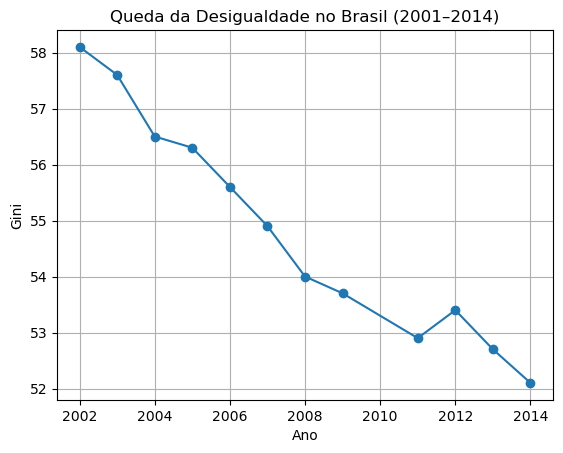

In [3]:
plt.figure()
plt.plot(df["ano"], df["gini"], marker="o")
plt.title("Queda da Desigualdade no Brasil (2001–2014)")
plt.xlabel("Ano")
plt.ylabel("Gini")
plt.grid()
plt.show()

# 4. Relações principais

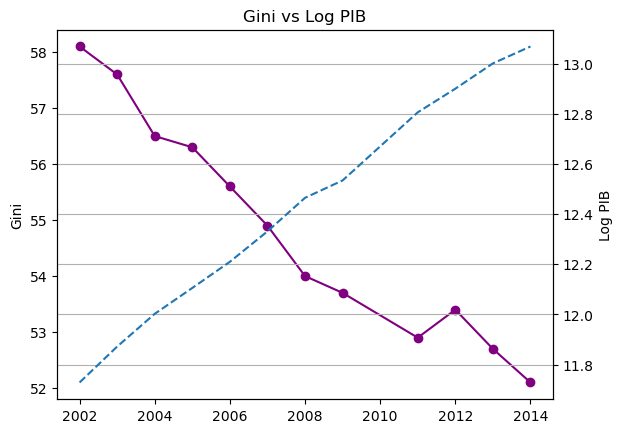

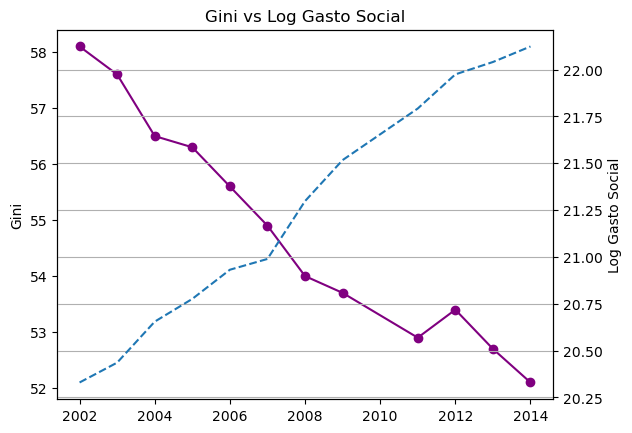

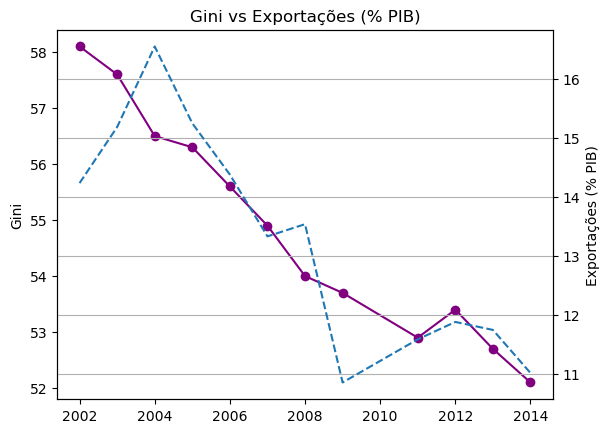

In [4]:
def plot_dual(y1, y2, label2):
    fig, ax1 = plt.subplots()
    
    ax1.plot(df["ano"], df["gini"], marker="o", label="Gini", color="purple")
    ax1.set_ylabel("Gini")
    
    ax2 = ax1.twinx()
    ax2.plot(df["ano"], y2, linestyle="--")
    ax2.set_ylabel(label2)
    
    plt.title(f"Gini vs {label2}")
    plt.grid()
    plt.show()

plot_dual(df["gini"], df["log_pib"], "Log PIB")
plot_dual(df["gini"], df["log_social"], "Log Gasto Social")
plot_dual(df["gini"], df["export_pct_gdp"], "Exportações (% PIB)")

# 5. Correlação

In [5]:
corr = df[[
    "gini",
    "log_pib",
    "log_social",
    "export_pct_gdp",
    "inflacao"
]].corr()

print(corr["gini"].sort_values())

log_pib          -0.978843
log_social       -0.974601
inflacao          0.563810
export_pct_gdp    0.849495
gini              1.000000
Name: gini, dtype: float64


# 6. Modelo V2 — Crescimento

In [6]:
X = df[[
    "pib_growth",
    "social_growth",
    "inflacao",
    "export_pct_gdp"
]]

y = df["gini"]

X = sm.add_constant(X)

model_growth = sm.OLS(y, X).fit()
print(model_growth.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     8.366
Date:                Sat, 02 May 2026   Prob (F-statistic):            0.00839
Time:                        18:47:28   Log-Likelihood:                -14.246
No. Observations:                  12   AIC:                             38.49
Df Residuals:                       7   BIC:                             40.92
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             42.9732      2.341     18.

# 7. Modelo com INTERAÇÃO

In [7]:
X = df[[
    "pib_growth",
    "social_growth",
    "estado_mercado"
]]

X = sm.add_constant(X)

model_interaction = sm.OLS(y, X).fit()
print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     64.92
Date:                Sat, 02 May 2026   Prob (F-statistic):           5.87e-06
Time:                        18:47:28   Log-Likelihood:                -5.3777
No. Observations:                  12   AIC:                             18.76
Df Residuals:                       8   BIC:                             20.69
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             84.3335      2.141     39.

# 8. Modelo por períodos

In [8]:
df_pre = df[df["ano"] <= 2008]
df_pos = df[df["ano"] >= 2009]

def run_model(data, label):
    X = data[[
        "pib_growth",
        "social_growth",
        "inflacao",
        "export_pct_gdp"
    ]]
    y = data["gini"]
    
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    
    print(f"\n===== {label} =====")
    print(model.summary())

run_model(df_pre, "Período Boom (2001–2008)")
run_model(df_pos, "Pós-crise (2009–2014)")


===== Período Boom (2001–2008) =====
                            OLS Regression Results                            
Dep. Variable:                   gini   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     7.218
Date:                Sat, 02 May 2026   Prob (F-statistic):              0.125
Time:                        18:47:28   Log-Likelihood:                -2.3939
No. Observations:                   7   AIC:                             14.79
Df Residuals:                       2   BIC:                             14.52
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const 

# 9. Contrafactual V2

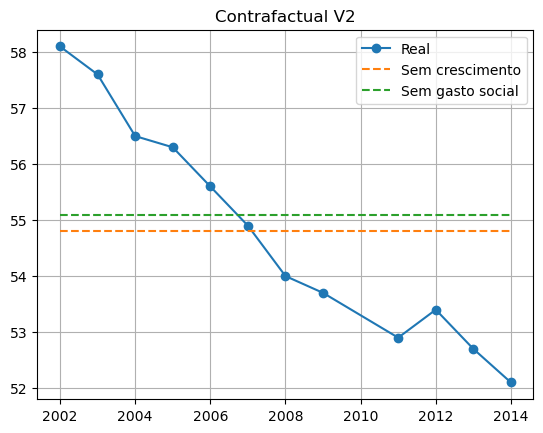

In [9]:
# modelo simples PIB
X_pib = sm.add_constant(df["pib_growth"])
model_pib = sm.OLS(df["gini"], X_pib).fit()

df_cf = df.copy()
df_cf["pib_growth"] = 0

X_cf = sm.add_constant(df_cf["pib_growth"], has_constant='add')
df_cf["gini_sem_crescimento"] = model_pib.predict(X_cf)

# modelo social
X_soc = sm.add_constant(df["social_growth"])
model_soc = sm.OLS(df["gini"], X_soc).fit()

df_cf["social_growth"] = 0
X_cf2 = sm.add_constant(df_cf["social_growth"], has_constant='add')
df_cf["gini_sem_social"] = model_soc.predict(X_cf2)

# plot
plt.figure()
plt.plot(df["ano"], df["gini"], marker="o", label="Real")
plt.plot(df["ano"], df_cf["gini_sem_crescimento"], linestyle="--", label="Sem crescimento")
plt.plot(df["ano"], df_cf["gini_sem_social"], linestyle="--", label="Sem gasto social")
plt.legend()
plt.grid()
plt.title("Contrafactual V2")
plt.show()